# Padding Analysis of the training transformation pipeline 

This notebook serves just as an investigation of the padding produced by the training transformation pipeline.

- It computes the fraction of valid image pixels after the training transformations and visualizes the highest padding fractions. 

- This analysis was considered to be relevant to REPA-Seg because increased padding reduces the amount of meaningful image content of patch tokens, which might affect the REPA loss.

The results were the basis on which i decided to increase the lower range scale from 0.5 to 0.75. 

Note, that there was no investigation conducted how this affects the training results. 
Would be interesting to investigate.  

In [4]:
from pathlib import Path
import torch.nn.functional as F
import os
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import sys

load_dotenv()

REPO_ROOT = Path(os.environ["REPO_ROOT"])
DATA_ROOT = Path(os.environ["DATA_ROOT"])
RUNS_ROOT = Path(os.environ["RUNS_ROOT"])

sys.path.insert(0, str(REPO_ROOT))

from preprocessing.transforms import TrainingTransforms, MEAN_IMAGENET, STD_IMAGENET


/home/h/haerlea/REPASeg/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(0.75, 2.0)
Valid pixel fraction analysis
Images: 20210
Mean valid fraction: 0.9708
Minimum valid fraction: 0.5625
Images with any padding:  20.01%
Mean padding fraction: 2.92%

Low-validity images:
  valid fraction < 0.25: 0.00%
  valid fraction < 0.50: 0.00%
  valid fraction < 0.75: 1.93%
  valid fraction < 0.90: 12.72%

Patch grid: 32 x 32
Mean patch weight: 0.9708
Fully valid patches (w = 1):96.74%
Partially valid (0 < w < 1): 0.67%
Fully padded patches (w = 0): 2.59%


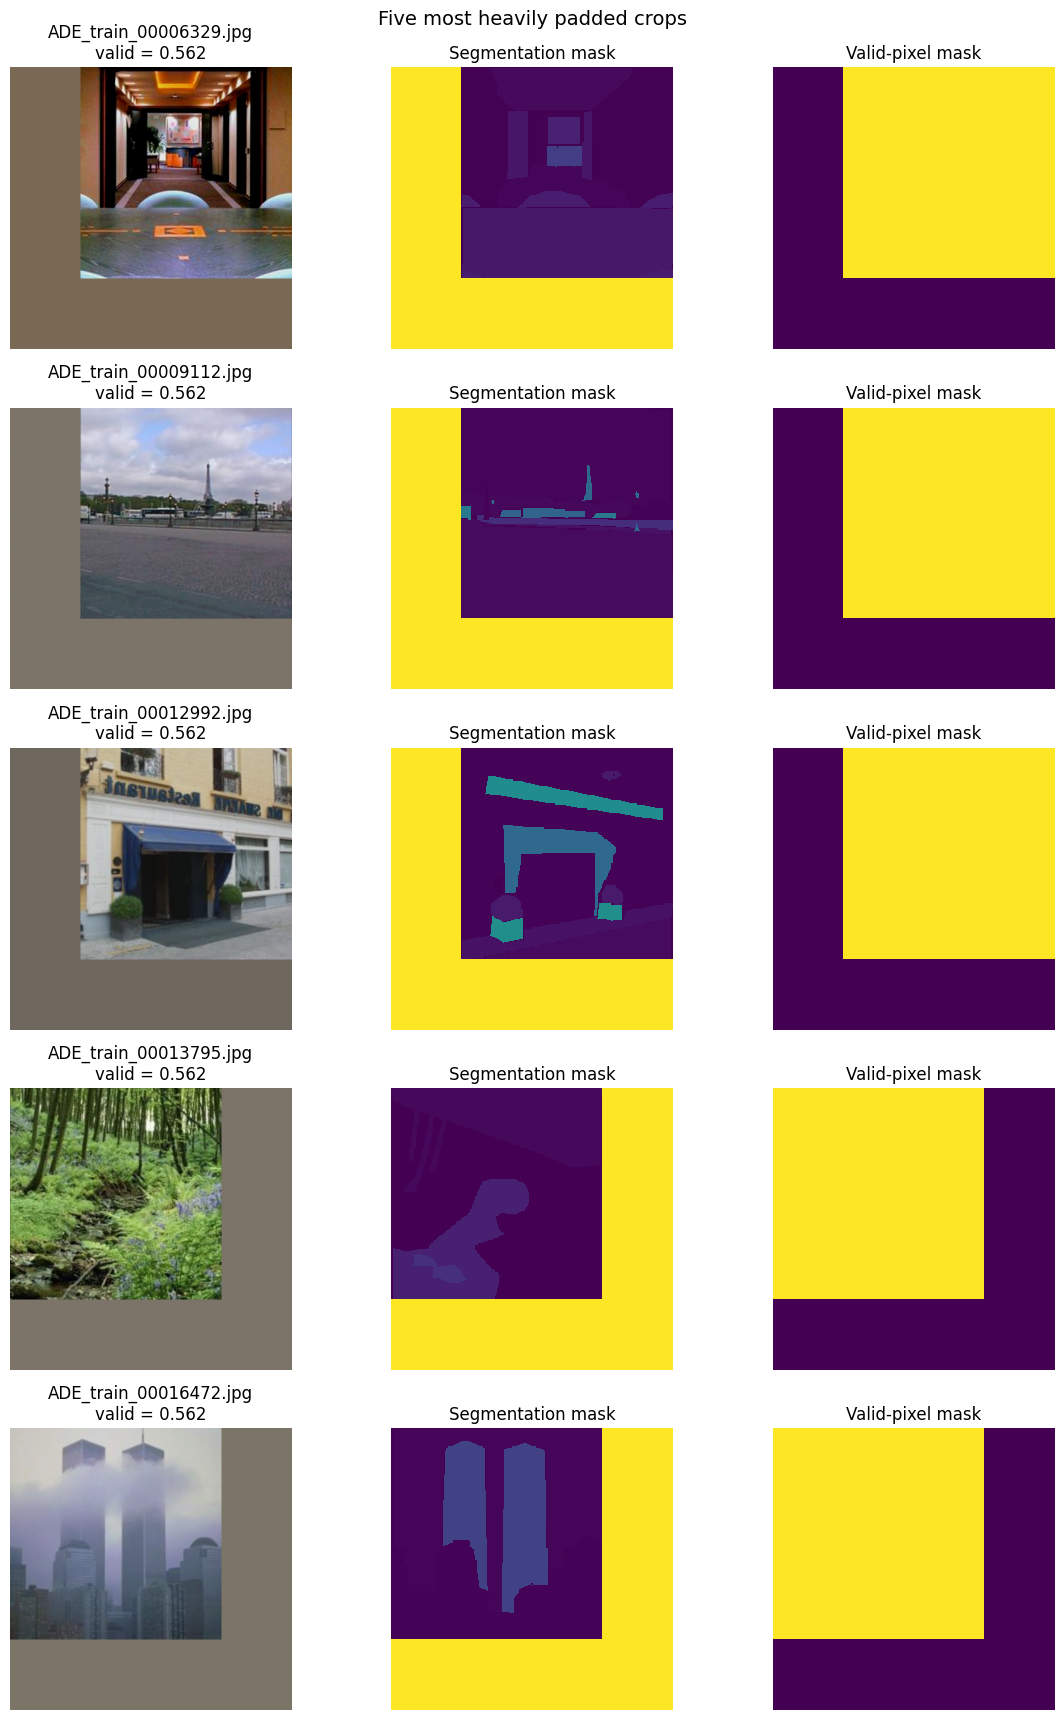

In [5]:
IMAGE_DIR = DATA_ROOT / "images" / "training"
MASK_DIR = DATA_ROOT / "annotations" / "training"

CROP_SIZE = 448
PATCH_SIZE = 14

transform = TrainingTransforms(
    crop_size=CROP_SIZE,patch_size=PATCH_SIZE,
    mean=MEAN_IMAGENET, std=STD_IMAGENET, color_jitter=True,     
    horizontal_flip=True,
    augmentation_strategy="baseline",
)

image_paths = sorted(IMAGE_DIR.glob("*.jpg"))
image_valid_fractions = []
patch_weights_all = []

examples = []

grid_size = CROP_SIZE // PATCH_SIZE

for idx, image_path in enumerate(image_paths):
    mask_path = MASK_DIR / f"{image_path.stem}.png"

    image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    out = transform(image=image, mask=mask)

    image_t = out["image"]
    mask_t = out["mask"]
    valid = out["valid_pixel_mask"]

    valid_fraction = valid.float().mean().item()
    image_valid_fractions.append(valid_fraction)

    # compute patch level valid fraction as in repa loss
    patch_weights = F.adaptive_avg_pool2d(
        valid.float()[None, None],
        output_size=(grid_size, grid_size),
    )[0, 0]

    patch_weights_all.append(patch_weights.flatten().numpy())

    examples.append({
        "path": image_path,
        "image": image_t.cpu(),
        "mask": mask_t.cpu(),
        "valid": valid.cpu(),
        "valid_fraction": valid_fraction,
    })

image_valid_fractions = np.asarray(image_valid_fractions)
patch_weights_all = np.concatenate(patch_weights_all)

print("Valid pixel fraction analysis")
print(f"Images: {len(image_valid_fractions)}")
print(f"Mean valid fraction: {image_valid_fractions.mean():.4f}")
print(f"Minimum valid fraction: {image_valid_fractions.min():.4f}")
print(f"Images with any padding:  {(image_valid_fractions < 1.0).mean() *100:.2f}%")
print(f"Mean padding fraction: {(1- image_valid_fractions).mean() *100:.2f}%")

print("\nLow-validity images:")
for threshold in [0.25, 0.50, 0.75, 0.90]:
    print(
        f"  valid fraction < {threshold:.2f}: "
        f"{(image_valid_fractions < threshold).mean() * 100:.2f}%"
    )

print(f"\nPatch grid: {grid_size} x {grid_size}")
print(f"Mean patch weight: {patch_weights_all.mean():.4f}")
print(f"Fully valid patches (w = 1):{(patch_weights_all == 1).mean() * 100:.2f}%")
print(f"Partially valid (0 < w < 1): {((patch_weights_all > 0) & (patch_weights_all < 1)).mean() * 100:.2f}%")
print(f"Fully padded patches (w = 0): {(patch_weights_all == 0).mean() * 100:.2f}%")

# VISUALIZATION
mean_t = torch.tensor(MEAN_IMAGENET).view(3, 1, 1)
std_t = torch.tensor(STD_IMAGENET).view(3, 1, 1)

def denormalize(x):
    return (x * std_t + mean_t).clamp(0, 1)

def show_examples(selected, title):
    n = len(selected)
    fig, axes = plt.subplots(n, 3, figsize=(12, 3.5 * n))

    if n == 1:
        axes = axes[None, :]
        
    for row, ex in enumerate(selected):
        img = denormalize(ex["image"]).permute(1, 2, 0).numpy()
        mask = ex["mask"].numpy()
        valid = ex["valid"].numpy()

        axes[row, 0].imshow(img)
        axes[row, 0].set_title(
            f"{ex['path'].name}\n"
            f"valid = {ex['valid_fraction']:.3f}"
        )

        axes[row, 1].imshow(mask,cmap="viridis", interpolation="nearest")
        axes[row, 1].set_title("Segmentation mask")
        axes[row, 2].imshow(valid,cmap="viridis", vmin=0, vmax=1, interpolation="nearest")
        axes[row, 2].set_title("Valid-pixel mask")

        for ax in axes[row]:
            ax.axis("off")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

worst = sorted(examples, key=lambda x: x["valid_fraction"])[:5]
show_examples(worst, "Five most heavily padded crops")

## Results of 2 passes
Note, that the exact values might be slighlty different for every pass. 

**Ratio (0.75, 2.0):**

Valid pixel fraction analysis  
Images: 20210  
Mean valid fraction: 0.9708  
Minimum valid fraction: 0.5625  
Images with any padding:  20.01%  
Mean padding fraction: 2.92%  

Low-validity images:  
  valid fraction < 0.25: 0.00%  
  valid fraction < 0.50: 0.00%  
  valid fraction < 0.75: 1.93%  
  valid fraction < 0.90: 12.72%  

Patch grid: 32 x 32  
Mean patch weight: 0.9708  
Fully valid patches (w = 1):96.74%  
Partially valid (0 < w < 1): 0.67%  
Fully padded patches (w = 0): 2.59%  

**Ratio (0.5, 2.0)  :**

Valid pixel fraction analysis  
Images: 20210  
Mean valid fraction: 0.8946  
Minimum valid fraction: 0.2500  
Images with any padding:  33.03%  
Mean padding fraction: 10.54%  

Low-validity images:  
  valid fraction < 0.25: 0.00%  
  valid fraction < 0.50: 8.24%  
  valid fraction < 0.75: 18.31%  
  valid fraction < 0.90: 27.02%  

Patch grid: 32 x 32  
Mean patch weight: 0.8946  
Fully valid patches (w = 1):88.85%  
Partially valid (0 < w < 1): 1.22%  
Fully padded patches (w = 0): 9.93%  
